In [20]:
import tensorflow as tf

import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras import backend as K

# the data, split between train and test sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(x_train.shape, y_train.shape)

x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
input_shape = (28, 28, 1)

# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train,10)
y_test = keras.utils.to_categorical(y_test,10)

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

batch_size = 128
num_classes = 10
epochs = 50

model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3),activation='relu',input_shape=input_shape))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss=keras.losses.categorical_crossentropy,optimizer=keras.optimizers.Adadelta(),metrics=['accuracy','precision','recall','f1_score'])

hist = model.fit(x_train, y_train,batch_size=batch_size,epochs=epochs,verbose=1,validation_data=(x_test, y_test))
print("The model has successfully trained")

model.save('mnist.h5')
print("Saving the model as mnist.h5")

score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

(60000, 28, 28) (60000,)
x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples
Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.1188 - f1_score: 0.0963 - loss: 2.2974 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.2641 - val_f1_score: 0.2330 - val_loss: 2.2355 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.2362 - f1_score: 0.2304 - loss: 2.2292 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.5331 - val_f1_score: 0.5328 - val_loss: 2.1499 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3779 - f1_score: 0.3767 - loss: 2.1440 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.6761 - val_f1_score: 0.6632 - val_loss: 2.0310 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4915 - f1_score: 0.4869 - loss

313/313 - 1s - 2ms/step - accuracy: 0.9240 - f1_score: 0.9230 - loss: 0.2606 - precision: 0.9447 - recall: 0.9053


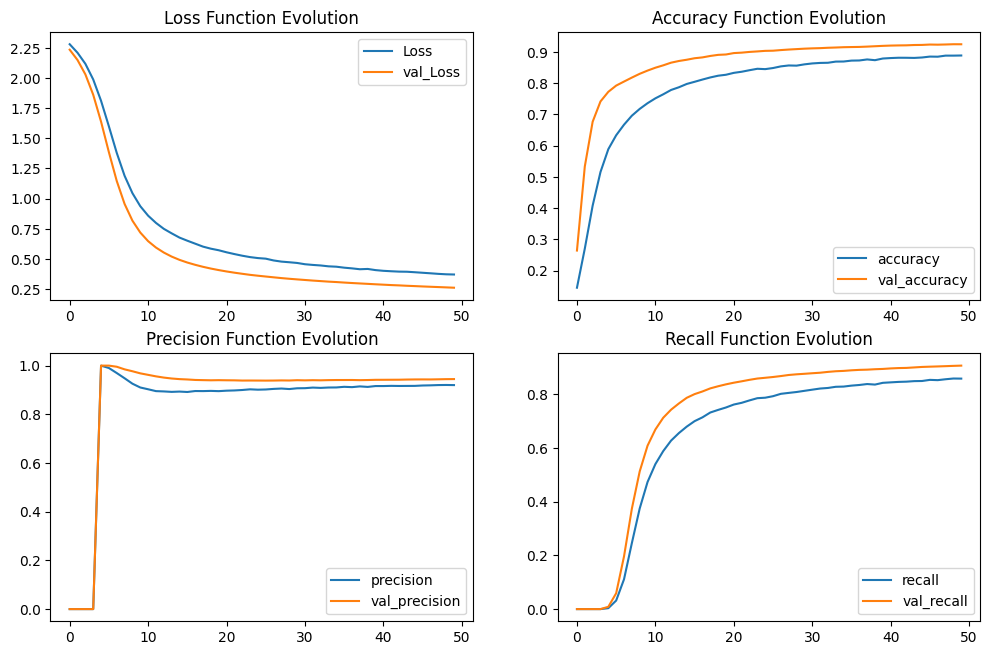

In [37]:
# Evaluate the model on the test data
results = model.evaluate(x_test, y_test, verbose=2)
test_loss = results[0]
test_accuracy = results[1]

plt.figure(figsize=(12, 16))

plt.subplot(4, 2, 1)
plt.plot(hist.history['loss'], label='Loss')
plt.plot(hist.history['val_loss'], label='val_Loss')
plt.title('Loss Function Evolution')
plt.legend()

plt.subplot(4, 2, 2)
plt.plot(hist.history['accuracy'], label='accuracy')
plt.plot(hist.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy Function Evolution')
plt.legend()

plt.subplot(4, 2, 3)
plt.plot(hist.history['precision'], label='precision')
plt.plot(hist.history['val_precision'], label='val_precision')
plt.title('Precision Function Evolution')
plt.legend()

plt.subplot(4, 2, 4)
plt.plot(hist.history['recall'], label='recall')
plt.plot(hist.history['val_recall'], label='val_recall')
plt.title('Recall Function Evolution')
plt.legend()

In [39]:
evaluation = model.evaluate(x_test, y_test)
print(f'Test Accuracy : {evaluation[1] * 100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9094 - f1_score: 0.9080 - loss: 0.3027 - precision: 0.9340 - recall: 0.8870
Test Accuracy : 92.40%


In [41]:
from sklearn.metrics import classification_report

# Generate predictions on the test dataset
y_pred = model.predict(x_test)

# Convert the predicted class probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert the true class labels to one-hot encoded format
y_test_classes = np.argmax(y_test, axis=1)

# Generate a classification report
report = classification_report(y_test_classes, y_pred_classes, target_names=['class 0', 'class 1', 'class 2', 'class 3', 'class 4', 'class 5', 'class 6', 'class 7', 'class 8', 'class 9'])
print(report)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

     class 0       0.94      0.98      0.96       980
     class 1       0.97      0.99      0.98      1135
     class 2       0.93      0.90      0.91      1032
     class 3       0.91      0.91      0.91      1010
     class 4       0.93      0.92      0.93       982
     class 5       0.92      0.88      0.90       892
     class 6       0.92      0.95      0.93       958
     class 7       0.93      0.91      0.92      1028
     class 8       0.89      0.90      0.89       974
     class 9       0.89      0.91      0.90      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [43]:
from sklearn.metrics import confusion_matrix

y_test_arg=np.argmax(y_test,axis=1)
Y_pred = np.argmax(model.predict(x_test),axis=1)
print('Confusion Matrix')
print(confusion_matrix(y_test_arg, Y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Confusion Matrix
[[ 961    0    0    1    0    2   10    1    5    0]
 [   0 1118    4    2    1    1    3    0    6    0]
 [  12    2  924   15   11    0   17   19   31    1]
 [   2    2   17  919    0   19    4   15   23    9]
 [   1    2    4    0  905    0   17    2    3   48]
 [  10    2    3   32    9  785   18    3   23    7]
 [  10    4    3    3    8   17  909    1    3    0]
 [   2   11   22    4   10    0    1  932    4   42]
 [   7    7    8   23    8   19    7   12  872   11]
 [  14    7    4   13   22    6    1   21    6  915]]


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


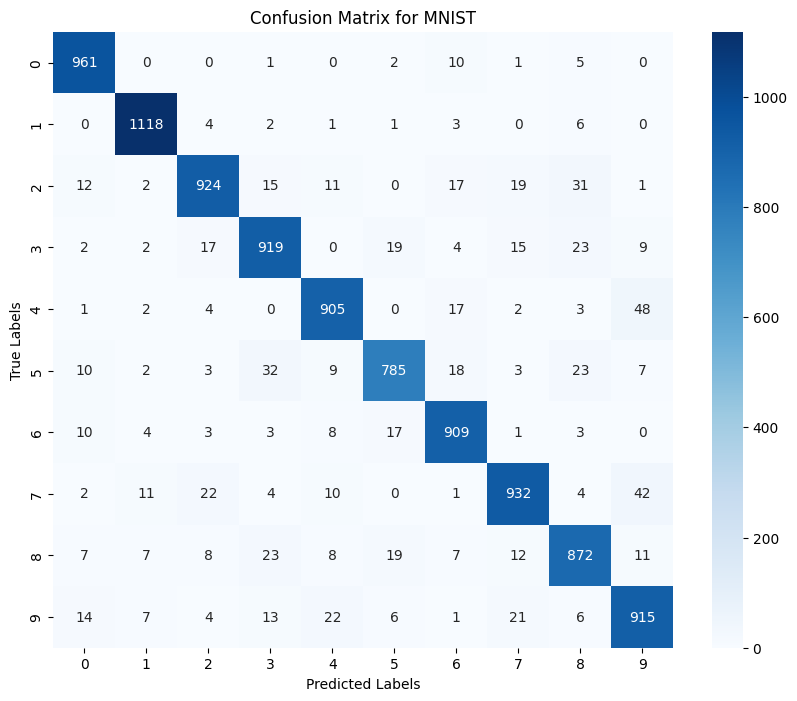

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Compute the confusion matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

# Plot the confusion matrix using seaborn for annotated numbers
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for MNIST')
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


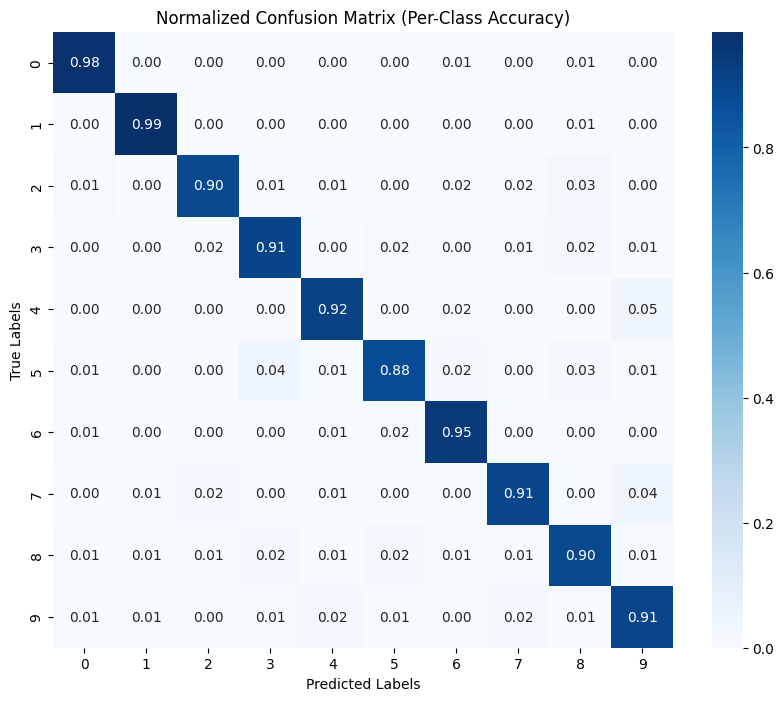

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

# Normalize (row-wise)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot normalized confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Normalized Confusion Matrix (Per-Class Accuracy)')
plt.show()


In [50]:
# Per-class accuracy
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, acc in enumerate(per_class_accuracy):
    print(f'Class {i}: {acc * 100:.2f}% accuracy')


Class 0: 98.06% accuracy
Class 1: 98.50% accuracy
Class 2: 89.53% accuracy
Class 3: 90.99% accuracy
Class 4: 92.16% accuracy
Class 5: 88.00% accuracy
Class 6: 94.89% accuracy
Class 7: 90.66% accuracy
Class 8: 89.53% accuracy
Class 9: 90.68% accuracy


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


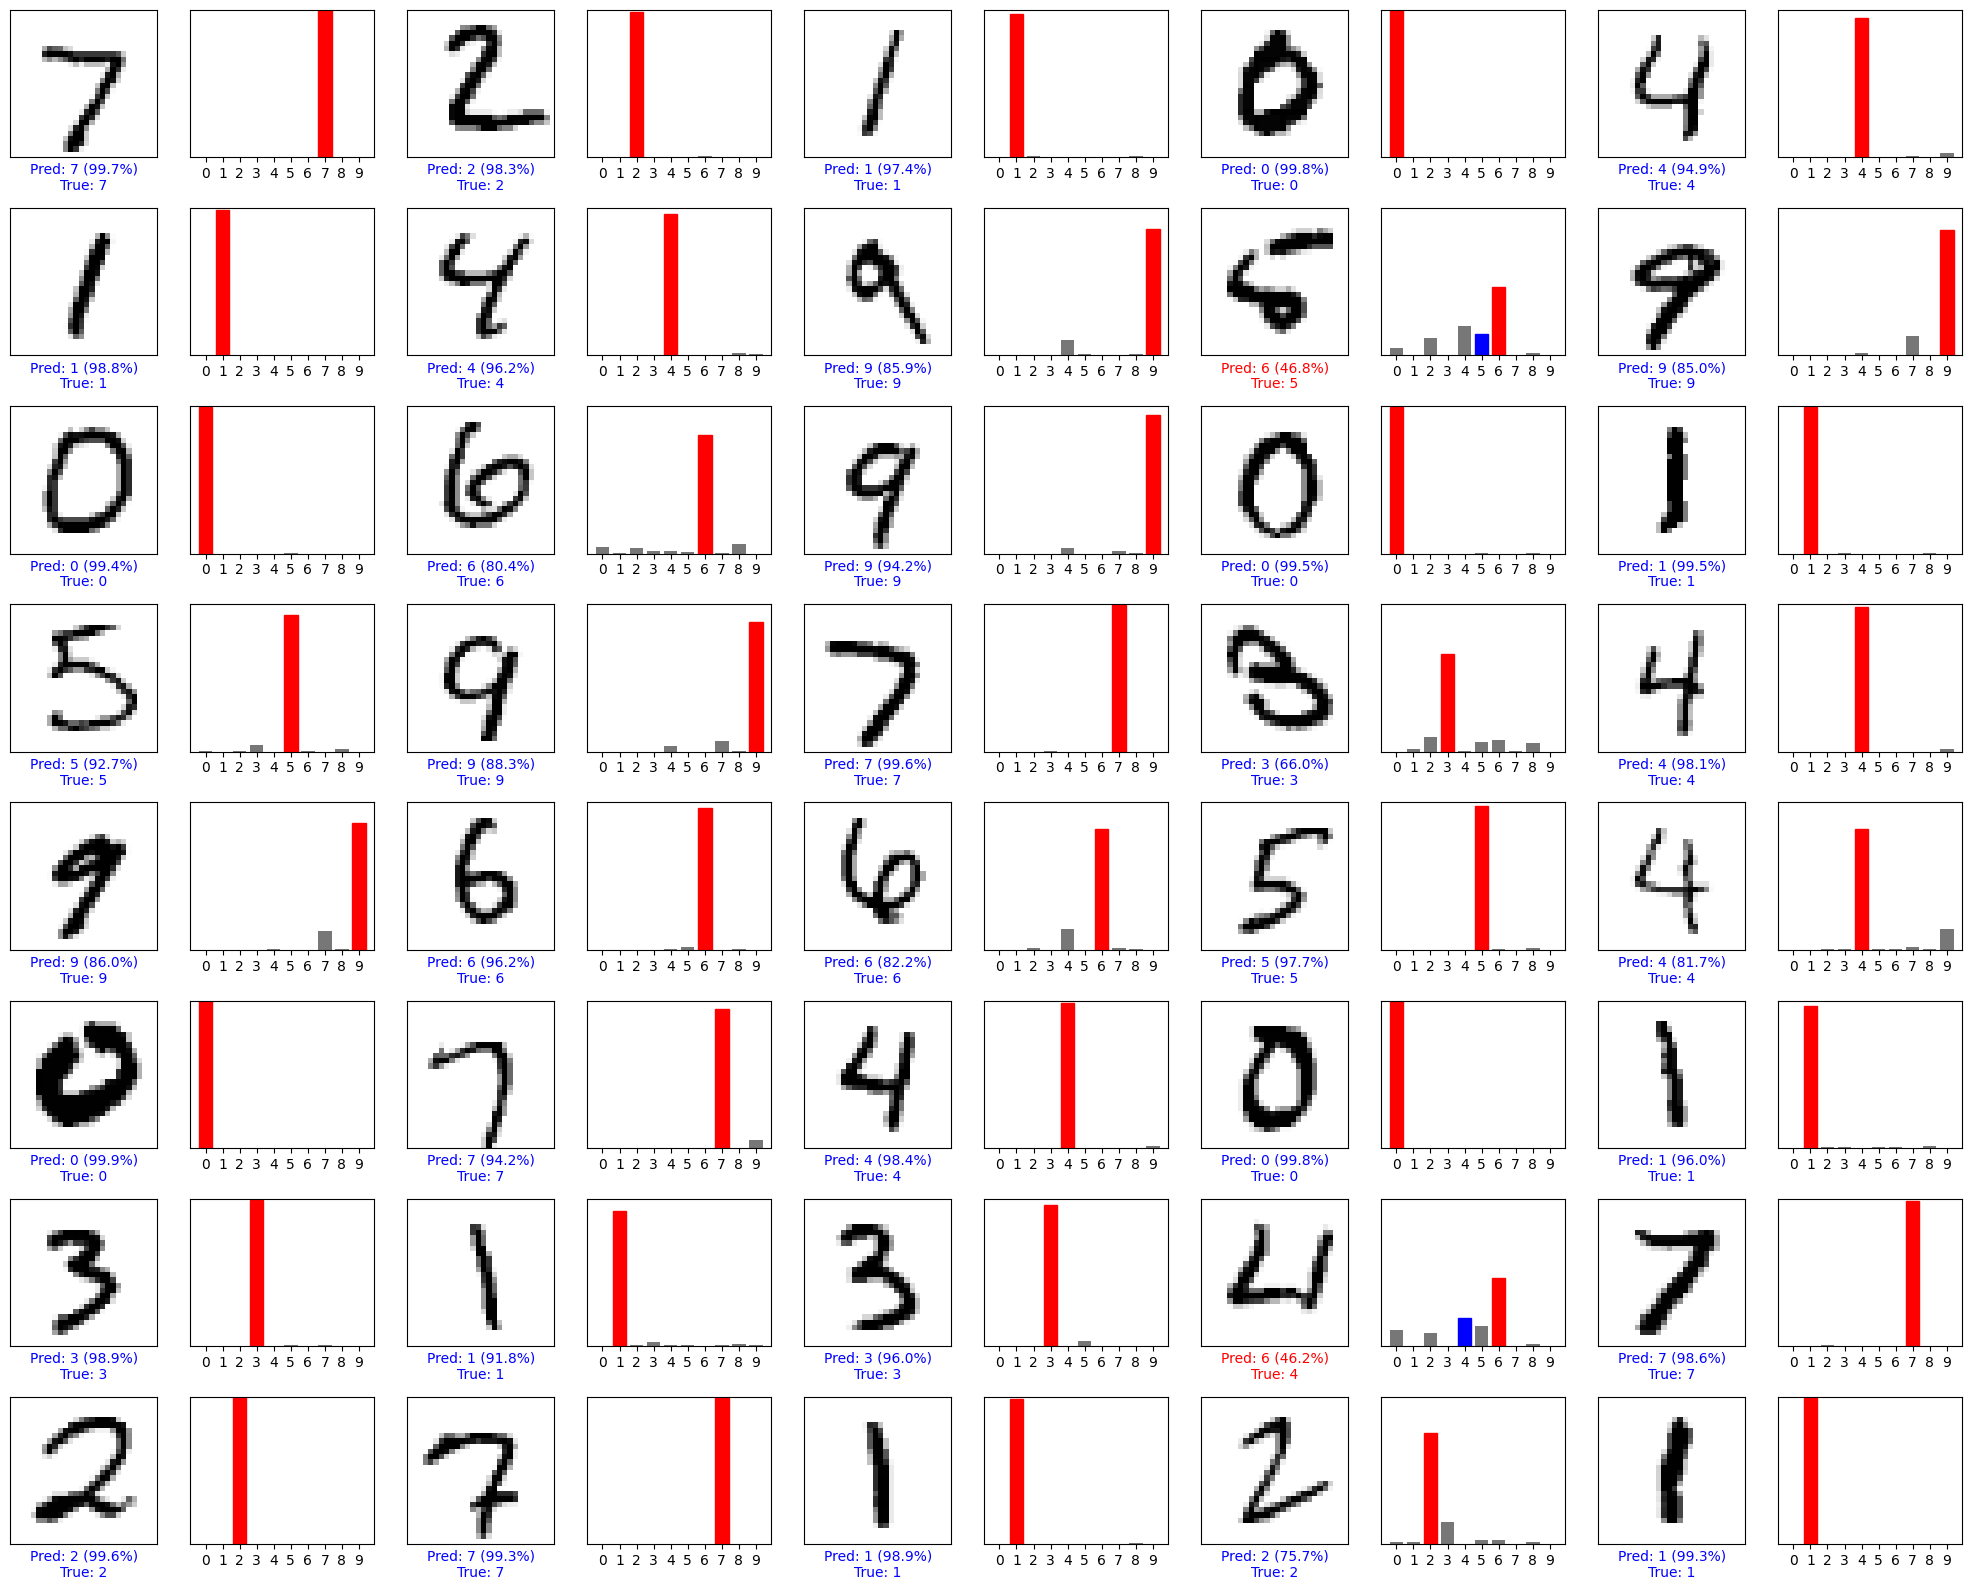

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure test labels are in class index format (not one-hot)
y_true = np.argmax(y_test, axis=1)
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

# Helper: plot image with prediction and label
def plot_image(i, predictions_array, true_label, img):
    predictions_array, true_label, img = predictions_array, true_label[i], img[i].reshape(28, 28)
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'

    plt.xlabel(f"Pred: {predicted_label} ({100*np.max(predictions_array):.1f}%)\nTrue: {true_label}",
               color=color)

# Helper: plot bar chart of class probabilities
def plot_value_array(i, predictions_array, true_label):
    predictions_array, true_label = predictions_array, true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    thisplot[true_label].set_color('blue')
    thisplot[np.argmax(predictions_array)].set_color('red')

# Plot multiple images with prediction bars
num_rows = 8
num_cols = 5
num_images = num_rows * num_cols
plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(i, predictions[i], y_true, x_test)
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plot_value_array(i, predictions[i], y_true)
plt.tight_layout()
plt.show()


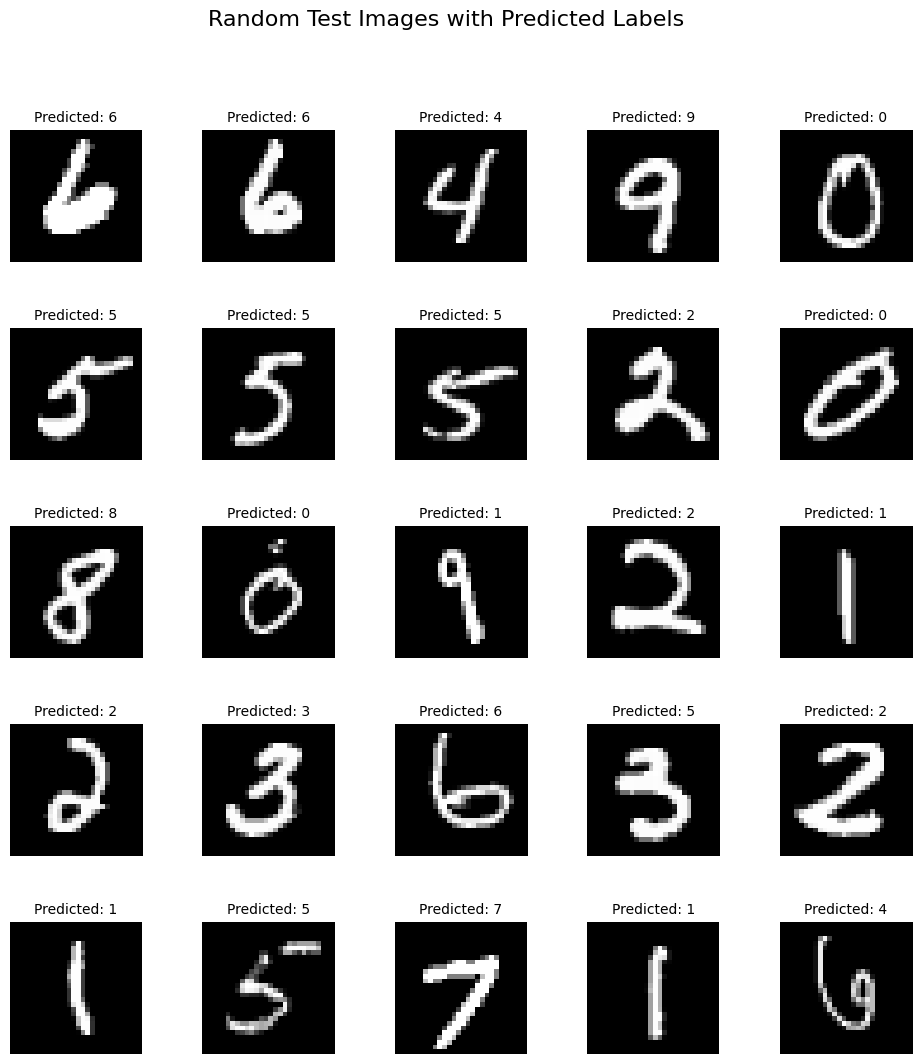

In [57]:
# Define the labels of the dataset
labels = ['0', '1', '2', '3', '4',
          '5', '6', '7', '8', '9']

# Grid dimensions
W_grid = 5
L_grid = 5

# Create the plot grid
fig, axes = plt.subplots(L_grid, W_grid, figsize=(12, 12))
axes = axes.ravel()

n_test = len(x_test)

# Show random test images with predicted labels
for i in np.arange(0, W_grid * L_grid):
    index = np.random.randint(0, n_test)

    axes[i].imshow(x_test[index].reshape(28, 28), cmap='gray')  # Reshape for display
    label_index = np.argmax(y_pred[index])  # Get predicted label
    axes[i].set_title(f"Predicted: {labels[label_index]}", fontsize=10)
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.5)
plt.suptitle("Random Test Images with Predicted Labels", fontsize=16)
plt.show()


In [70]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

#Load the trained Keras model from the .h5 file
model = load_model('mnist.h5')

# Extract weights from the Keras model
keras_weights = model.get_weights()

# Define the PyTorch model
class MNISTModel(nn.Module):
    def __init__(self):
        super(MNISTModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.fc1 = nn.Linear(64 * 7 * 7, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

# Instantiate the PyTorch model
model_pytorch = MNISTModel()

# Transfer Keras weights to PyTorch model
model_pytorch.conv1.weight.data = torch.from_numpy(keras_weights[0]).permute(3, 2, 0, 1)
model_pytorch.conv1.bias.data = torch.from_numpy(keras_weights[1])

model_pytorch.conv2.weight.data = torch.from_numpy(keras_weights[2]).permute(3, 2, 0, 1)
model_pytorch.conv2.bias.data = torch.from_numpy(keras_weights[3])

model_pytorch.fc1.weight.data = torch.from_numpy(keras_weights[4]).T
model_pytorch.fc1.bias.data = torch.from_numpy(keras_weights[5])

model_pytorch.fc2.weight.data = torch.from_numpy(keras_weights[6]).T
model_pytorch.fc2.bias.data = torch.from_numpy(keras_weights[7])




In [71]:
# Save the PyTorch model as .pt file
torch.save(model_pytorch.state_dict(), 'MNIST_Model.pt')